In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [121]:
data = pd.read_csv('ParisHousing.csv', sep=";")

In [122]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   squareMeters       10000 non-null  int64  
 1   numberOfRooms      10000 non-null  int64  
 2   hasYard            10000 non-null  int64  
 3   hasPool            10000 non-null  int64  
 4   floors             10000 non-null  int64  
 5   cityCode           10000 non-null  int64  
 6   cityPartRange      10000 non-null  int64  
 7   numPrevOwners      10000 non-null  int64  
 8   made               10000 non-null  int64  
 9   isNewBuilt         10000 non-null  int64  
 10  hasStormProtector  10000 non-null  int64  
 11  basement           10000 non-null  int64  
 12  attic              10000 non-null  int64  
 13  garage             10000 non-null  int64  
 14  hasStorageRoom     10000 non-null  int64  
 15  hasGuestRoom       10000 non-null  int64  
 16  price              1000

In [123]:
data

,squareMeters,numberOfRooms,hasYard,hasPool,floors,cityCode,cityPartRange,numPrevOwners,made,isNewBuilt,hasStormProtector,basement,attic,garage,hasStorageRoom,hasGuestRoom,price
0,75523,3,0,1,63,9373,3,8,2005,0,1,4313,9005,956,0,7,7559081.5
1,80771,39,1,1,98,39381,8,6,2015,1,0,3653,2436,128,1,2,8085989.5
2,55712,58,0,1,19,34457,6,8,2021,0,0,2937,8852,135,1,9,5574642.1
3,32316,47,0,0,6,27939,10,4,2012,0,1,659,7141,359,0,3,3232561.2
4,70429,19,1,1,90,38045,3,7,1990,1,0,8435,2429,292,1,4,7055052.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1726,89,0,1,5,73133,7,6,2009,0,1,9311,1698,218,0,4,176425.9
9996,44403,29,1,1,12,34606,9,4,1990,0,1,9061,1742,230,0,0,4448474.0
9997,83841,3,0,0,69,80933,10,10,2005,1,1,8304,7730,345,1,9,8390030.5
9998,59036,70,0,0,96,55856,1,3,2010,0,1,2590,6174,339,1,4,5905107.0


array([[<Axes: title={'center': 'squareMeters'}>,
        <Axes: title={'center': 'numberOfRooms'}>,
        <Axes: title={'center': 'hasYard'}>,
        <Axes: title={'center': 'hasPool'}>],
       [<Axes: title={'center': 'floors'}>,
        <Axes: title={'center': 'cityCode'}>,
        <Axes: title={'center': 'cityPartRange'}>,
        <Axes: title={'center': 'numPrevOwners'}>],
       [<Axes: title={'center': 'made'}>,
        <Axes: title={'center': 'isNewBuilt'}>,
        <Axes: title={'center': 'hasStormProtector'}>,
        <Axes: title={'center': 'basement'}>],
       [<Axes: title={'center': 'attic'}>,
        <Axes: title={'center': 'garage'}>,
        <Axes: title={'center': 'hasStorageRoom'}>,
        <Axes: title={'center': 'hasGuestRoom'}>],
       [<Axes: title={'center': 'price'}>, <Axes: >, <Axes: >, <Axes: >]],
      dtype=object)

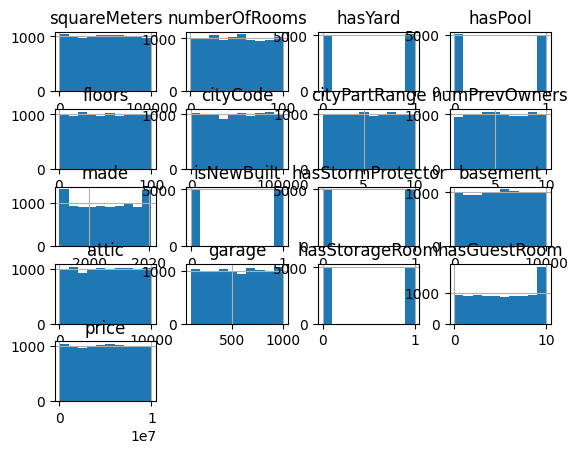

In [124]:
data.hist()

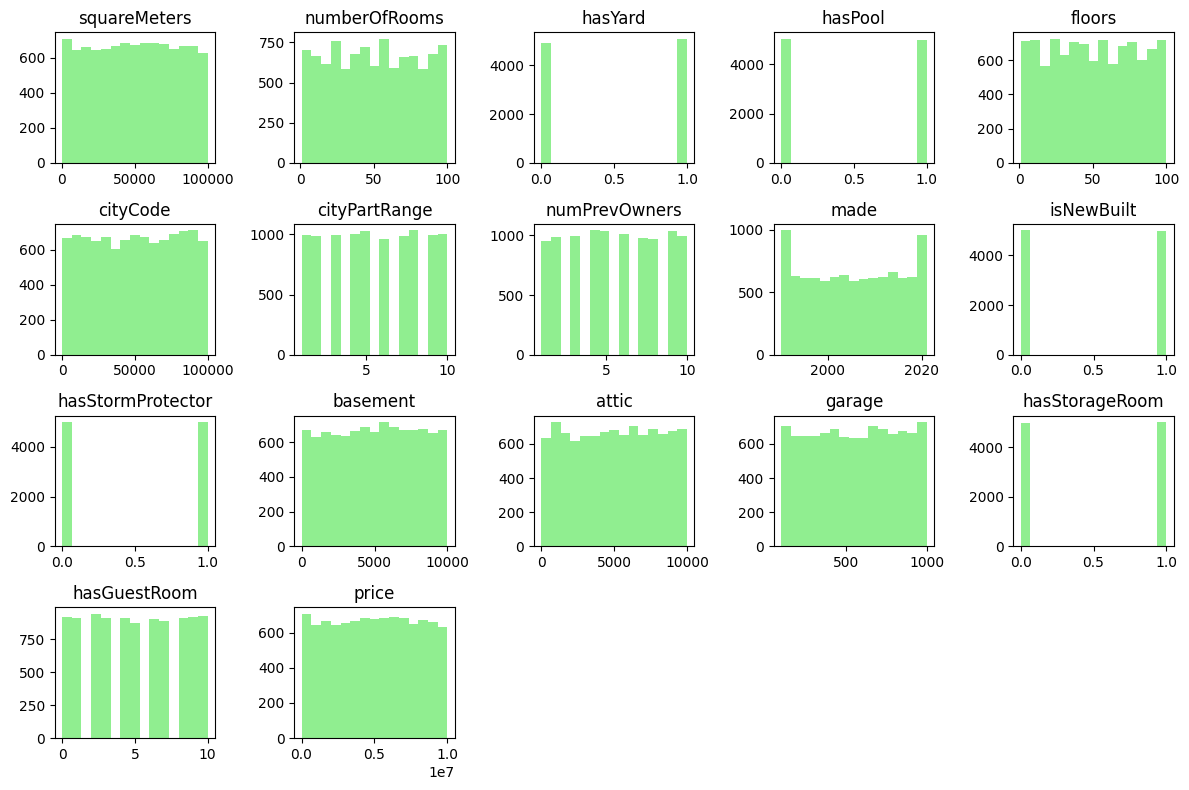

In [125]:
# Метод 2: Гистограммы всех числовых столбцов
data.hist(figsize=(12, 8), bins=15, color='lightgreen', 
grid=False, layout=(4, 5))
plt.tight_layout()
plt.show()


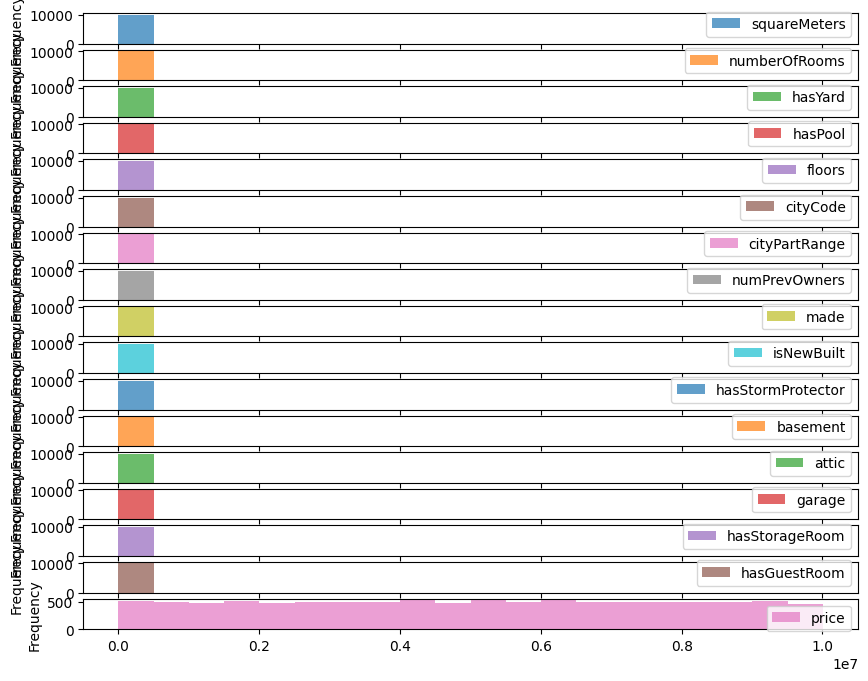

In [126]:

# Метод 3: Использование plot.hist()
data.plot.hist(alpha=0.7, bins=20, subplots=True, 
layout=(17, 1), figsize=(10, 8))
plt.show()

<Axes: >

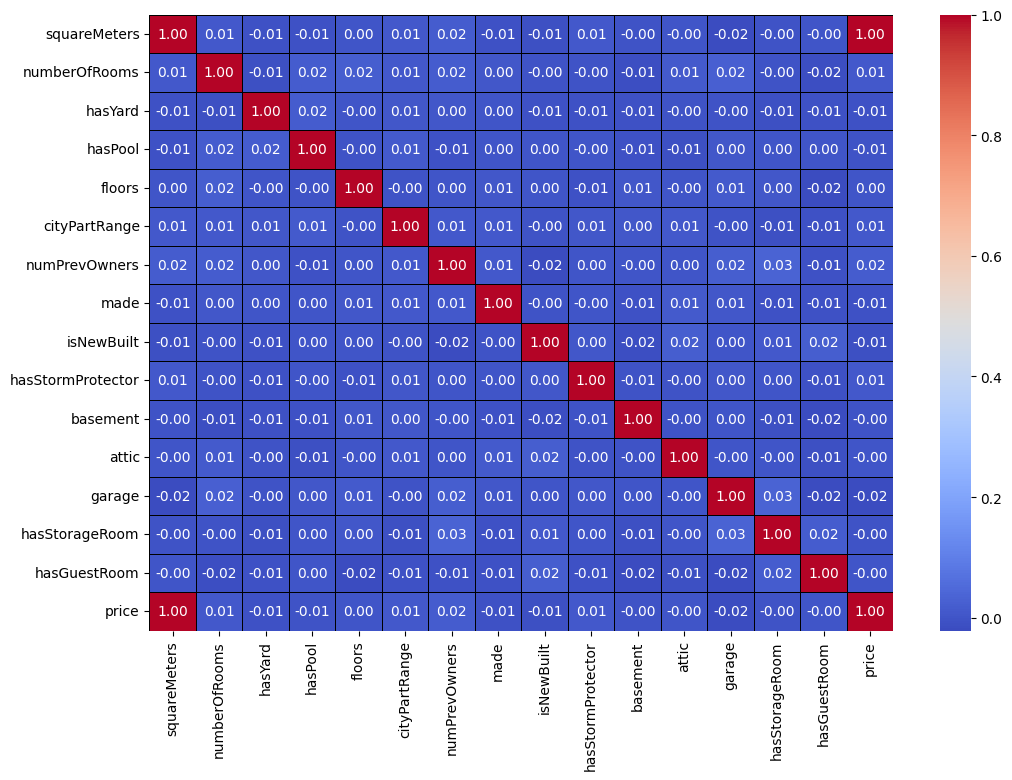

In [127]:
numeric_cols = data.select_dtypes(include=['number']).columns.drop(['cityCode'])
plt.figure(figsize=(12, 8))
sns.heatmap(data=data[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.6, linecolor='black')

In [128]:
plt.scatter()

TypeError: scatter() missing 2 required positional arguments: 'x' and 'y'

In [129]:
X, y = data[['squareMeters','numberOfRooms','hasGuestRoom','hasPool']], data['price']/10000
#
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

y_train = y_train.values.reshape(-1, 1)
y_test = y_test.values.reshape(-1, 1)

# Нормализация
scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train)
#
X_test_scaled = scaler.transform(X_test)

# Нормализация y_train
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
#
y_test_scaled = scaler_y.transform(y_test)

In [130]:
y_train.shape

(7000, 1)

In [132]:
class SimpleNeuroNet:
    def __init__(self, input_size, learning_rate = 0.001, alpha = 0.01):
        self.input_size = input_size
        self.learning_rate = learning_rate
        self.w1 = np.random.randn(input_size+1, 2)
        self.w2 = np.random.randn(3, 1)
        self.alpha = alpha

    def add_ones(self, X):
        return np.c_[X, np.ones(len(X))]
    
    def sigmoid(self, z):
        return 1/(1 + np.exp(-z))
    
    def d_sigmoid(self, z):
        return self.sigmoid(z) * (1 - self.sigmoid(z))
    
    def leakyReLU(self, z):
        return np.where(z<0, self.alpha*z, z)
    
    def d_leakyReLU(self, z):
        return np.where(z<0, self.alpha, 1)

    def forward(self, X):
        X = self.add_ones(X) # (N, input_size+1)
        #
        #Второй слой
        self.z1 = X @ self.w1 # (N, 2)
        h1 = self.leakyReLU(self.z1) # (N, 2)
        self.h1 = self.add_ones(h1) # (N, 3)
        #
        #Третий слой
        z2 = self.h1 @ self.w2 # (N, 3) @ (3, 1) = (N, 1)
        return(z2) #добавили ravel из-за ошибки
    
    def backward(self, X, y, y_pred):
        N = len(y_pred)
        dL_dz2 = (y_pred - y) * 2/N # поменяли знаки
        dL_dw2 = self.h1.T @ dL_dz2 # (3, N) @ (N, 1) -> (3, 1)
        #
        #print(dL_dz2.shape, self.w2.shape) # проверяем на ошибку
        dL_dh1 = dL_dz2 @ self.w2[:-1].T # (N, 1) @ (1, 2) -> (N, 2)
        dL_dz1 = dL_dh1 * self.d_leakyReLU(self.z1) # (N, 2) * (N, 2) -> (N, 2)
        # dz1_dw1 = X    # z1 = w1*x
        dL_dw1 = self.add_ones(X).T @ dL_dz1 # (input_size+1, N) @ (N, 2) -> (input_size+1, 2)
        #
        self.w1 = self.w1 - self.learning_rate * dL_dw1 #(input_size+1, 2)
        self.w2 = self.w2 - self.learning_rate * dL_dw2 #(3, 1)

    def train(self, X_train, y_train, epoh = 1000):
        for i in range(epoh):
            y_pred = self.forward(X_train)#.reshape(-1, 1)
            #print(y_pred.shape)
            self.backward(X_train, y_train, y_pred)
            # Расчет MSE
            mse = np.mean((y_train - y_pred) ** 2)
            # Логирование
            if i % 10 == 0:
                print(f"Итерация {i} | MSE: {mse:.6f}")

    def predict(self, X):
        return self.forward(X)


In [133]:
y_train.shape

(7000, 1)

In [134]:
y_predict.shape

(3000, 1)

In [135]:
model = SimpleNeuroNet(X_train_scaled.shape[1])
model.train(X_train_scaled, y_train)

y_predict = model.predict(X_test_scaled)

Итерация 0 | MSE: 326728.021321
Итерация 10 | MSE: 2534.264747
Итерация 20 | MSE: 22494.329351
Итерация 30 | MSE: 22368.029832
Итерация 40 | MSE: 22283.950126
Итерация 50 | MSE: 22188.066400
Итерация 60 | MSE: 22079.628629
Итерация 70 | MSE: 21966.268356
Итерация 80 | MSE: 21852.035167
Итерация 90 | MSE: 21735.703492
Итерация 100 | MSE: 21617.583838
Итерация 110 | MSE: 21498.427620
Итерация 120 | MSE: 21383.348517
Итерация 130 | MSE: 21265.186085
Итерация 140 | MSE: 21144.712090
Итерация 150 | MSE: 21025.606688
Итерация 160 | MSE: 20907.641993
Итерация 170 | MSE: 20789.192087
Итерация 180 | MSE: 20671.383407
Итерация 190 | MSE: 20551.511697
Итерация 200 | MSE: 20432.419364
Итерация 210 | MSE: 20313.842869
Итерация 220 | MSE: 20195.532004
Итерация 230 | MSE: 20077.173909
Итерация 240 | MSE: 19959.620882
Итерация 250 | MSE: 19843.442962
Итерация 260 | MSE: 19728.105496
Итерация 270 | MSE: 19613.319599
Итерация 280 | MSE: 19499.127516
Итерация 290 | MSE: 19384.726107
Итерация 300 | MSE: 1

/var/folders/jz/08_61t5j3l709y2kg70phbq40000gn/T/ipykernel_15855/3687222366.py:28: RuntimeWarning: divide by zero encountered in matmul
  self.z1 = X @ self.w1 # (N, 2)
/var/folders/jz/08_61t5j3l709y2kg70phbq40000gn/T/ipykernel_15855/3687222366.py:28: RuntimeWarning: overflow encountered in matmul
  self.z1 = X @ self.w1 # (N, 2)
/var/folders/jz/08_61t5j3l709y2kg70phbq40000gn/T/ipykernel_15855/3687222366.py:28: RuntimeWarning: invalid value encountered in matmul
  self.z1 = X @ self.w1 # (N, 2)
/var/folders/jz/08_61t5j3l709y2kg70phbq40000gn/T/ipykernel_15855/3687222366.py:33: RuntimeWarning: divide by zero encountered in matmul
  z2 = self.h1 @ self.w2 # (N, 3) @ (3, 1) = (N, 1)
/var/folders/jz/08_61t5j3l709y2kg70phbq40000gn/T/ipykernel_15855/3687222366.py:33: RuntimeWarning: overflow encountered in matmul
  z2 = self.h1 @ self.w2 # (N, 3) @ (3, 1) = (N, 1)
/var/folders/jz/08_61t5j3l709y2kg70phbq40000gn/T/ipykernel_15855/3687222366.py:33: RuntimeWarning: invalid value encountered in ma

<Axes: >

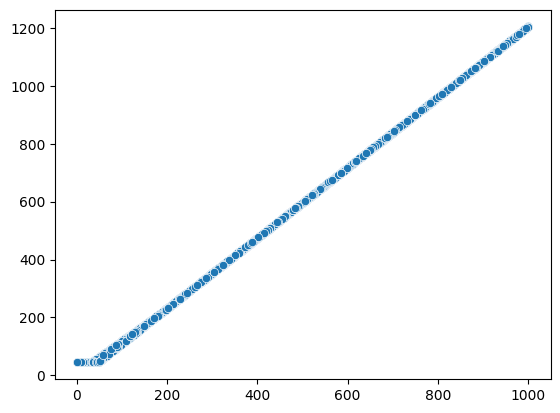

In [136]:
sns.scatterplot(x=y_test.ravel(), y=y_predict.ravel())

![alt text](image-2.png)

In [137]:

np.random.randn(5+1, 2)

array([[ 0.50206323, -1.39802711],
       [-0.37377529,  0.18544493],
       [ 0.08002408, -1.94617791],
       [-0.67551489,  0.01267993],
       [-0.72891079,  0.6638936 ],
       [ 0.4862653 , -0.08021481]])

In [138]:
y_train_scaled.mean(), y_train_scaled.std()

(np.float64(2.791417890486108e-17), np.float64(1.0))

In [156]:
class SVR:
    def __init__(self, n_iter=500, learning_rate=0.0001):
        self.n_iter = n_iter
        self.learning_rate = learning_rate
        self.weights = None  # Новый параметр для хранения весов модели
        self.b = 1
        self.eps = (y_train_scaled.max() - y_train_scaled.min())*0.1

    def fit(self, X, y, verbose=False):
        self.weights = np.ones(X.shape[1])

        for epoch in range(self.n_iter):
            for i in range(X.shape[0]):
                x_i = X[i,:]
                y_i = y[i,:]
                y_pred = self.weights.T @ x_i + self.b
                print(y_pred)
                error = y_pred - y_i #ошибка предсказания

                if np.abs(error) <= self.eps:
                    gradient_w = 0
                    gradient_b = 0
                elif error > self.eps:
                    gradient_w = x_i
                    gradient_b = 1
                elif -error > self.eps:
                    gradient_w = -x_i
                    gradient_b = -1

                self.weights = self.weights - self.learning_rate * gradient_w
                self.b = self.b - self.learning_rate * gradient_b
            
            #loss = np.mean(np.maximum(0, abs(y-(X @ self.weights + self.b)) - self.eps))
            loss = 0

            if verbose != False and epoch%verbose == 0:
                print(f'{epoch} | loss: {loss:.5f}')
    
    def get_coef(self):
        return(self.weights, self.b)
                


In [144]:
X_train_scaled.shape

(7000, 4)

In [157]:
model = SVR(X_train_scaled.shape[1])
model.fit(X_train_scaled, y_train, verbose=1)

#y_predict = model.predict(X_test_scaled)

2.5057485130028283
-1.100302474299755
-1.498852017657589
2.19723944424594
4.600333205881303
0.5476181190234161
-1.806742803343294
-3.112160699753508
2.178273400072364
-0.8325192579284735
0.13723564041872716
2.134388952019113
2.8437498510567663
2.4527354011987827
-0.37442863030463847
-2.0374374646829274
-1.5785753361858301
2.3692291037706004
-0.5093257747628903
-1.0492477138685337
-0.652106447846057
0.7751118366885674
2.3886806896074066
2.29126856502618
-0.42497535281716003
-0.7529349274884416
0.1571984432481217
-1.6951534051253823
-0.4792468338870859
0.8942110080527352
0.9730299137841172
-1.740067617894036
0.07861263005230024
1.3137065719742427
-2.2420855389042713
2.357038940931548
0.539588846938253
-1.562146408341463
0.22321261037978646
3.085673259426776
-1.559376699088551
1.4604075726827916
2.320448958506702
0.3713516741753897
-0.885663393856631
2.258926109217474
2.703757550008447
1.9783959012340062
-0.9327145713708305
-0.05145215246240786
0.3285656155251766
-3.0689337108589596
0.952